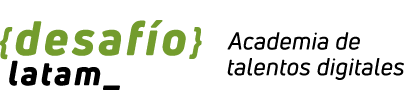

# <center><font color="green">Regresión (parte I)</font></center>

## <font color="green">Matriz de correlaciones</font>

Python nos permite determinar fácilmente las correlaciones entre cada par de variables contenidas en un dataset. En nuestro caso, utilizaremos los datos correspondientes a la base de datos de los pingüinos que vimos en la sesión anterior.


In [3]:
#cargamos las bibliotecas y la data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

from matplotlib.colors import ListedColormap
from scipy import stats
from scipy.stats import norm, skew
from sklearn import preprocessing

# Cargar el conjunto de datos de pingüinos de seaborn
penguins = sns.load_dataset("penguins")

# Filtrar los datos sin valores faltantes
data = penguins.dropna()
data



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [5]:
data1 = data[["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm", ]]


In [6]:
data1.corr()

,flipper_length_mm,body_mass_g,bill_length_mm,bill_depth_mm
flipper_length_mm,1.000000,0.872979,0.653096,-0.577792
body_mass_g,0.872979,1.000000,0.589451,-0.472016
bill_length_mm,0.653096,0.589451,1.000000,-0.228626
bill_depth_mm,-0.577792,-0.472016,-0.228626,1.000000


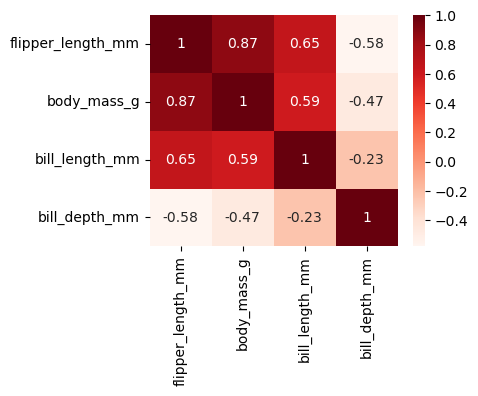

In [7]:
plt.figure(figsize=(4,3))
sns.heatmap(data1.corr(), annot=True, cmap=plt.cm.Reds)
'''
PuBu utiliza una gamna de colores en púrpura. Otras alternativas son:
- Viridis (cmap=plt.cm.viridis): es especialmente útil para representar datos
cuantitativos. Tiene una transición suave y uniforme de colores, lo que facilita
la interpretación de las relaciones.

- Coolwarm (cmap=plt.cm.coolwarm): Este es un mapa de color divergente que va
desde colores fríos (azules) a colores cálidos (rojos). Puede ser útil cuando
deseas resaltar diferencias positivas y negativas en tus datos.

- Greens (cmap=plt.cm.Greens): en tonos de verde

Reds (cmap=plt.cm.Reds): En tonos rojos

YlGnBu (cmap=plt.cm.YlGnBu): va desde amarillo hasta azul, pasando por tonos
verdes.

Pastel1 (cmap=plt.cm.Pastel1): Tonos pasteles

Accent (cmap=plt.cm.Accent): Tonos brillantes
'''
plt.show()

In [8]:
data1.corr()

,flipper_length_mm,body_mass_g,bill_length_mm,bill_depth_mm
flipper_length_mm,1.000000,0.872979,0.653096,-0.577792
body_mass_g,0.872979,1.000000,0.589451,-0.472016
bill_length_mm,0.653096,0.589451,1.000000,-0.228626
bill_depth_mm,-0.577792,-0.472016,-0.228626,1.000000


<center><strong>¡Podemos regresar a nuestra presentación!</strong></center>

## <font color="green">Regresión lineal simple</font>


In [11]:
econometria: 
SM.OLS

machine learning
Linar regresion (sk learn)

SyntaxError: invalid syntax (2492762576.py, line 1)

Vamos a analizar, a partir de nuestra base de datos, las posibles relaciones entre las variables que presenta.

In [13]:
data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Vamos a examinar primero la posible relación entre las variables. Crearemos ahora un scatterplot, para visualizar la distribución de los pesos y largos de las aletas. Para ello, primero seleccionaremos esas columnas.

In [16]:
# Filtrar las columnas necesarias
data1 = data[["flipper_length_mm", "body_mass_g"]]

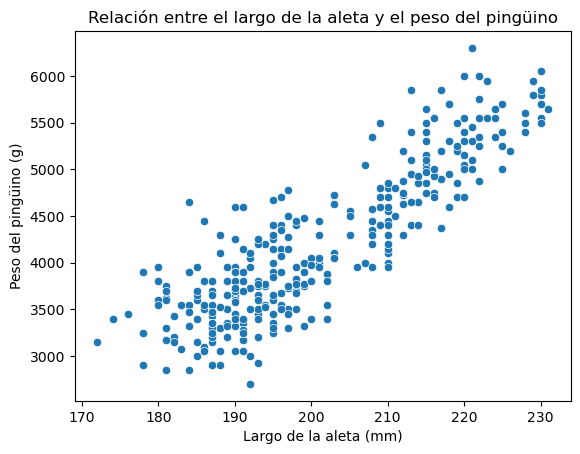

In [18]:
# Crear una gráfica de dispersión
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", data=data1)
plt.title("Relación entre el largo de la aleta y el peso del pingüino")
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Peso del pingüino (g)")
plt.show()

Intuitivamente, parece haber una correlación lineal positiva que verificaremos a continuación.

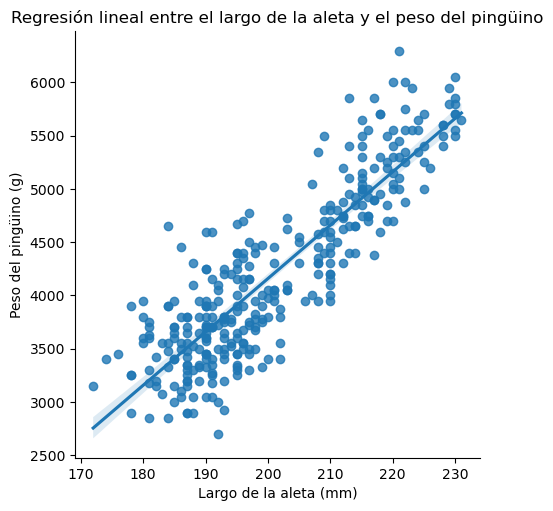

Pendiente: 50.15326594224111
Intercepto: -5872.092682842823
Error estándar: 1.5402309838246344
Coef. de correlación: 0.8729788985653613


In [21]:
# Realizar la regresión lineal
sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=data1)
plt.title("Regresión lineal entre el largo de la aleta y el peso del pingüino")
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Peso del pingüino (g)")

# Calcular los valores de la regresión lineal. Ya veremos el significado de los parámetros
slope, intercept, r_value, p_value, std_err = stats.linregress(data["flipper_length_mm"], data["body_mass_g"])

# Mostrar el gráfico completo
plt.show()

print(f"Pendiente: {slope}")
print(f"Intercepto: {intercept}")
print(f"Error estándar: {std_err}")
print(f"Coef. de correlación: {r_value}")

Podemos analizar ahora lo que ocurre con los residuos, lo que más adelante nos permitirá evaluar nuestro modelo.

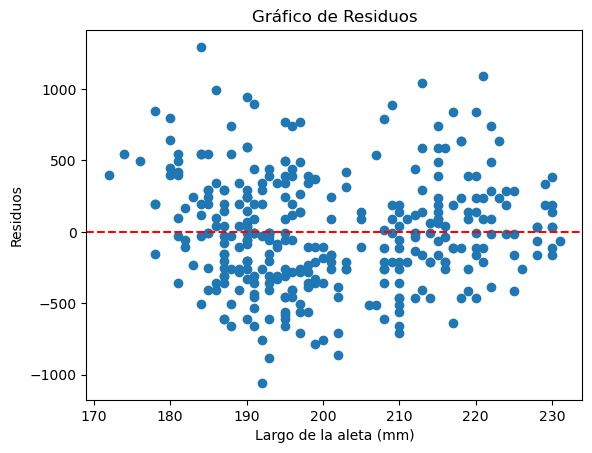

In [23]:
residuals = data["body_mass_g"] - (slope * data["flipper_length_mm"] + intercept)

# Mostrar un gráfico de los residuos
plt.figure()
plt.scatter(data["flipper_length_mm"], residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Gráfico de Residuos")
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Residuos")
plt.show()

Podríamos ver algo más aquí sobre regresión lineal múltiple, pero para ello necesitaremos algunas herramientas más.

## <font color = 'green'>Modelo de regresión lineal con Statsmodels</font>

Utilizaremos un módulo llamado statsmodels, que tiene documentación[ aquí](https://www.statsmodels.org/stable/gettingstarted.html).

El módulo statsmodels proporciona una amplia variedad de estadísticas de salida y parámetros de ajuste. Consulta la documentación completa de la regresión statsmodels [aquí](https://www.statsmodels.org/stable/regression.html).

Statsmodels contiene una función llamada .OLS() para realizar una regresión, buscando minimizar los cuadrados de los residuos. Un detalle importante es que se necesita agregar una columna de "1" a las variables predictoras, ya que esto (por motivos más largos de explicar) permite realizar un mejor ajuste del modelo.

In [28]:
import statsmodels.api as sm

#Definir las variables predictoras (X) y la variable de respuesta (y)
X = data["flipper_length_mm"]
y = data["body_mass_g"]

# Agregar una constante al predictor (intercepto)
X = sm.add_constant(X)

In [29]:
X

,const,flipper_length_mm
0,1.0,181.0
1,1.0,186.0
2,1.0,195.0
4,1.0,193.0
5,1.0,190.0
...,...,...
338,1.0,214.0
340,1.0,215.0
341,1.0,222.0
342,1.0,212.0


In [32]:
# Crear y ajustar el modelo
model = sm.OLS(y, X).fit()

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          3.13e-105
Time:                        23:59:31   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5872.0927    310.28

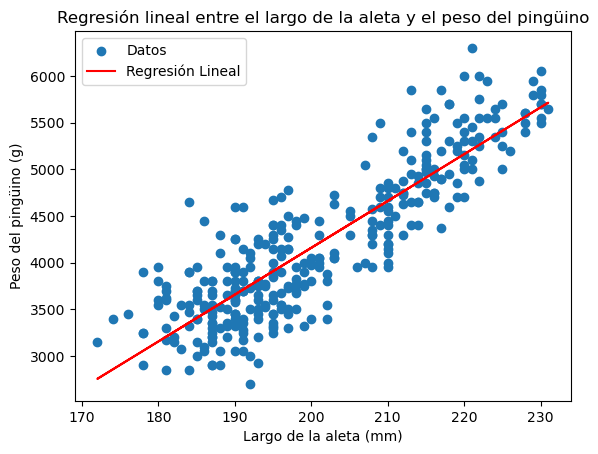

In [34]:

# Obtener los resultados del modelo
results = model.summary()

# Imprimir los resultados
print(results)

# Graficar la regresión lineal
plt.scatter(data["flipper_length_mm"], data["body_mass_g"], label="Datos")
plt.plot(data["flipper_length_mm"], model.predict(X), color='red', label="Regresión Lineal")
plt.title("Regresión lineal entre el largo de la aleta y el peso del pingüino")
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Peso del pingüino (g)")
plt.legend()
plt.show()



Podemos aplicar statsmodels para obtener un modelo de regresión para dos o más variables independientes. En nuestro caso, vamos a definir como variables independientes el largo de la aleta y el sexo; para esto último deberemos transformar esta variable categórica en numerica utilizando get.dummies

In [37]:

# Paso 1: Definir variables predictoras (X) y variable de respuesta (y)
X = data[['flipper_length_mm', 'sex']]  # Largo de la aleta y sexo como variables independientes
y = data['body_mass_g']  # Peso como variable dependiente

In [39]:
# Codificar la variable categórica 'sex' usando get dummies
#X_encoded = pd.get_dummies(X, columns=['sex'], prefix=['sex']).astype(int)
X_encoded2 = pd.get_dummies(X, drop_first= True).astype(int)
# Paso 2: Agregar una constante (intercepto) a las variables predictoras
X_encoded2 = sm.add_constant(X_encoded2)

In [41]:
X_encoded2

,const,flipper_length_mm,sex_Male
0,1.0,181,1
1,1.0,186,0
2,1.0,195,0
4,1.0,193,0
5,1.0,190,1
...,...,...,...
338,1.0,214,0
340,1.0,215,0
341,1.0,222,1
342,1.0,212,0


In [43]:

# Paso 3: Crear el modelo de regresión lineal
model = sm.OLS(y, X_encoded2).fit()

# Paso 4: Obtener resultados del modelo
results = model.summary()

predictions = model.predict(X_encoded2)

# Calcular el Error Cuadrático Medio (MSE)
mse = ((y - predictions) ** 2).mean()

# Calcular el Error Cuadrático Medio Explicado (EMSE)
emse = mse / ((y - y.mean()) ** 2).mean()

# Obtener el valor R² del modelo
r2 = model.rsquared

print(results)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Error Mean Squared Explicado (EMSE): {emse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")


                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          3.53e-118
Time:                        23:59:32   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5410.3002    285.79

In [45]:
# 354 (gramos)

¿Cómo podemos interpretar los resultados que nos entrega statsmodels?



<center><strong>¡Ahora podemos regresar a nuestra presentación!<center><strong>




In [48]:
# Eliminar filas con valores faltantes
data_cleaned = data.dropna(subset=['body_mass_g', 'flipper_length_mm'])

# Filtrar los datos por género (macho y hembra)
pinguinos_macho = data_cleaned[data_cleaned['sex'] == 'Male']
pinguinos_hembra = data_cleaned[data_cleaned['sex'] == 'Female']

# Crear modelos de regresión lineal para cada género y para ambos juntos
model_macho = sm.OLS(pinguinos_macho['flipper_length_mm'], sm.add_constant(pinguinos_macho['body_mass_g'])).fit()
model_hembra = sm.OLS(pinguinos_hembra['flipper_length_mm'], sm.add_constant(pinguinos_hembra['body_mass_g'])).fit()
model_ambos = sm.OLS(data_cleaned['flipper_length_mm'], sm.add_constant(data_cleaned['body_mass_g'])).fit()

# Obtener las predicciones de cada modelo
predictions_macho = model_macho.predict()
predictions_hembra = model_hembra.predict()
predictions_ambos = model_ambos.predict()

# Calcular el Error Cuadrático Medio (MSE) para cada modelo
mse_macho = ((pinguinos_macho['flipper_length_mm'] - predictions_macho) ** 2).mean()
mse_hembra = ((pinguinos_hembra['flipper_length_mm'] - predictions_hembra) ** 2).mean()
mse_ambos = ((data_cleaned['flipper_length_mm'] - predictions_ambos) ** 2).mean()

# Calcular el Error Cuadrático Medio Explicado (EMSE) para cada modelo
emse_macho = mse_macho / ((pinguinos_macho['flipper_length_mm'] - pinguinos_macho['flipper_length_mm'].mean()) ** 2).mean()
emse_hembra = mse_hembra / ((pinguinos_hembra['flipper_length_mm'] - pinguinos_hembra['flipper_length_mm'].mean()) ** 2).mean()
emse_ambos = mse_ambos / ((data_cleaned['flipper_length_mm'] - data_cleaned['flipper_length_mm'].mean()) ** 2).mean()

# Calcular el Coeficiente de Determinación (R²) para cada modelo
r2_macho = model_macho.rsquared
r2_hembra = model_hembra.rsquared
r2_ambos = model_ambos.rsquared

# Calcular el Error Absoluto Medio (MAE) para cada modelo
mae_macho = (abs(pinguinos_macho['flipper_length_mm'] - predictions_macho)).mean()
mae_hembra = (abs(pinguinos_hembra['flipper_length_mm'] - predictions_hembra)).mean()
mae_ambos = (abs(data_cleaned['flipper_length_mm'] - predictions_ambos)).mean()


# Mostrar los resultados
print("Modelo para pingüinos macho:")
print(f"R²: {r2_macho:.2f}, MSE: {mse_macho:.2f}, EMSE: {emse_macho:.2f}, MAE: {mae_macho:.2f}")

print("\nModelo para pingüinos hembra:")
print(f"R²: {r2_hembra:.2f}, MSE: {mse_hembra:.2f}, EMSE: {emse_hembra:.2f}, MAE: {mae_hembra:.2f}")

print("\nModelo para ambos géneros juntos:")
print(f"R²: {r2_ambos:.2f}, MSE: {mse_ambos:.2f}, EMSE: {emse_ambos:.2f}, MAE: {mae_ambos:.2f}")


Modelo para pingüinos macho:
R²: 0.75, MSE: 52.79, EMSE: 0.25, MAE: 6.04

Modelo para pingüinos hembra:
R²: 0.78, MSE: 33.72, EMSE: 0.22, MAE: 4.59

Modelo para ambos géneros juntos:
R²: 0.76, MSE: 46.59, EMSE: 0.24, MAE: 5.56


Analizando las mpetricas obtenidas tenemos que:

* El Coeficiente de Determinación (R²) indica la proporción de la variabilidad total en la variable dependiente que es explicada por el modelo. Cuanto más cercano a 1 sea el R², mejor es el ajuste del modelo a los datos. En este sentido, podemos ver que los modelos son similares en cuanto a nivel de ajuste.

*  El Error Cuadrático Medio (MSE) mide la magnitud promedio de los errores cuadrados entre las predicciones del modelo y los valores reales. Un MSE más bajo indica que el modelo tiene errores más pequeños y, por lo tanto, es mejor en términos de precisión. En este sentido, el modelo para las pingüinos hembra es notoriamente más preciso que los otros dos.

* El Error Cuadrático Medio Explicado (EMSE) es una variante del MSE que normaliza el error al dividirlo por la varianza de la variable dependiente. Permite comparar modelos en términos de la capacidad del modelo para explicar la variabilidad en los datos en relación con la varianza natural de los datos.
Un EMSE más bajo indica que el modelo es mejor para explicar la variabilidad en los datos. En este sentido, el modelo para las hembras es levemente mejor que los demás.

* El Error Absoluto Medio (MAE) mide la magnitud promedio de los errores absolutos entre las predicciones del modelo y los valores reales.
Es menos sensible a valores atípicos que el MSE, ya que no eleva los errores al cuadrado. Un modelo con un MAE más bajo se considera mejor en términos de precisión.

Podemos graficar para observar las relaciones.



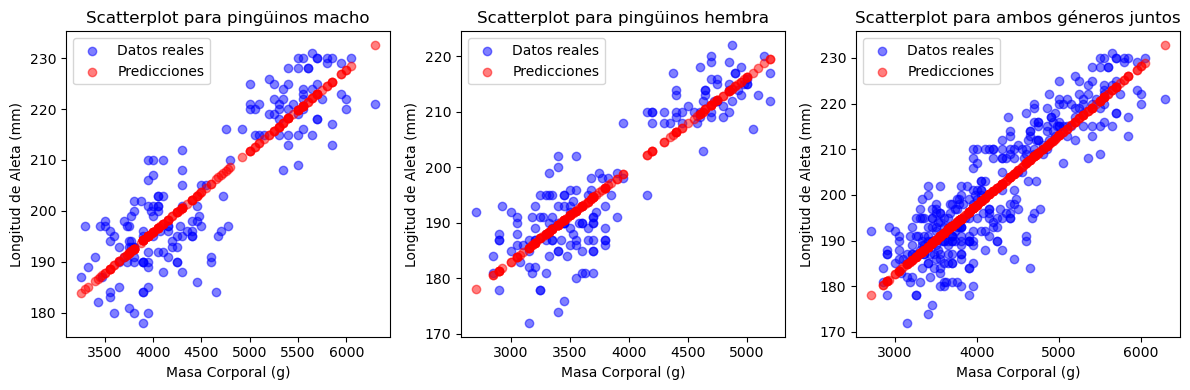

In [51]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(pinguinos_macho['body_mass_g'], pinguinos_macho['flipper_length_mm'], label='Datos reales', color='blue', alpha=0.5)
plt.scatter(pinguinos_macho['body_mass_g'], predictions_macho, label='Predicciones', color='red', alpha=0.5)
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Longitud de Aleta (mm)')
plt.title('Scatterplot para pingüinos macho')
plt.legend()

# Scatterplot para los pingüinos hembra
plt.subplot(1, 3, 2)
plt.scatter(pinguinos_hembra['body_mass_g'], pinguinos_hembra['flipper_length_mm'], label='Datos reales', color='blue', alpha=0.5)
plt.scatter(pinguinos_hembra['body_mass_g'], predictions_hembra, label='Predicciones', color='red', alpha=0.5)
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Longitud de Aleta (mm)')
plt.title('Scatterplot para pingüinos hembra')
plt.legend()

# Scatterplot para ambos géneros juntos
plt.subplot(1, 3, 3)
plt.scatter(data_cleaned['body_mass_g'], data_cleaned['flipper_length_mm'], label='Datos reales', color='blue', alpha=0.5)
plt.scatter(data_cleaned['body_mass_g'], predictions_ambos, label='Predicciones', color='red', alpha=0.5)
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Longitud de Aleta (mm)')
plt.title('Scatterplot para ambos géneros juntos')
plt.legend()

# Mostrar los scatterplots
plt.tight_layout()
plt.show()

## <font color="green">Modelo de regresión lineal con Scikit-Learn</font>

A continuación, implementaremos el modelo utilizando `scikit-learn`. Dividiremos los datos en conjuntos de entrenamiento (para ajustar el modelo) y prueba (para evaluar su rendimiento predictivo con datos nuevos).

Separación de muestras (train 70%) entrenamiento, test (prueba 30%)
67 - 33


Pendiente: 50.42
Intercepto: -5919.26
Error Cuadrático Medio (MSE): 129886.72
Coeficiente de Determinación (R²): 0.79


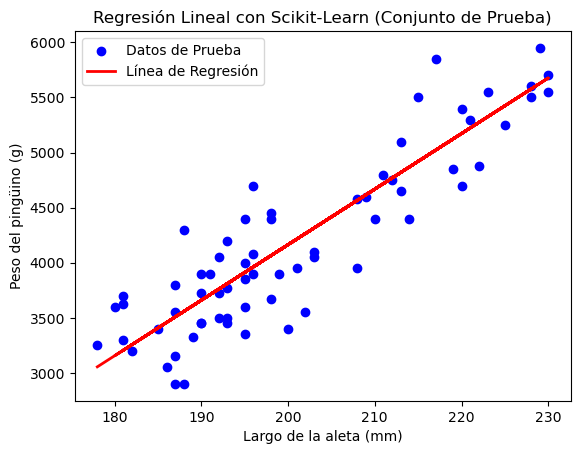

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Definir variable predictora (X) y objetivo (y). X debe ser un arreglo 2D.
X_skl = data[['flipper_length_mm']]
y_skl = data['body_mass_g']

# 2. Dividir los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_skl, y_skl, test_size=0.2, random_state=42)

# 3. Inicializar y entrenar el modelo
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_train, y_train) # esta entrenado solo con el 80%

# 4. Realizar predicciones sobre el conjunto de prueba
y_pred = modelo_sklearn.predict(X_test) # está prediciendo sobre el 20%

# 5. Extraer métricas y parámetros
mse_skl = mean_squared_error(y_test, y_pred) # dif entre lo real y lo predicho
r2_skl = r2_score(y_test, y_pred)# dif entre lo real y lo predicho

print(f"Pendiente: {modelo_sklearn.coef_[0]:.2f}")
print(f"Intercepto: {modelo_sklearn.intercept_:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse_skl:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_skl:.2f}")

# 6. Graficar los datos de prueba frente a la línea de predicción
plt.scatter(X_test, y_test, color='blue', label='Datos de Prueba')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de Regresión')
plt.title("Regresión Lineal con Scikit-Learn (Conjunto de Prueba)")
plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Peso del pingüino (g)")
plt.legend()
plt.show()

In [66]:
#solo de ejemplo
# 1. Generar predicciones para el set de entrenamiento
y_hat_train = modelo_sklearn.predict(X_train) # 80% de la data

# 2. Crear una copia de X_train para no afectar el original y añadir las columnas
df_entrenamiento = X_train.copy()
df_entrenamiento['Peso_Real'] = y_train
df_entrenamiento['Peso_Predicho_y_hat'] = y_hat_train.round(2)

# 3. Mostrar el resultado
print("Comparativa en el conjunto de Entrenamiento:")
display(df_entrenamiento.head())

Comparativa en el conjunto de Entrenamiento:


,flipper_length_mm,Peso_Real,Peso_Predicho_y_hat
230,214.0,4650.0,4870.19
84,191.0,3350.0,3710.58
303,224.0,5350.0,5374.37
22,189.0,3800.0,3609.74
29,180.0,3950.0,3155.98


In [69]:

# 1. Preparación de los Subconjuntos (Asegúrate que 'df' sea tu DataFrame base)
# Filtramos eliminando nulos en las columnas críticas
df_clean = data.dropna(subset=['body_mass_g', 'flipper_length_mm', 'sex'])

macho = df_clean[df_clean['sex'] == 'Male']
hembra = df_clean[df_clean['sex'] == 'Female']
data_cleaned = df_clean # El set completo

def entrenar_y_evaluar(df, etiqueta):
    # Validar que el subset no esté vacío
    if df.empty:
        print(f"--- {etiqueta}: Sin datos suficientes ---")
        return

    # Preparar X e y
    X = df[['body_mass_g']]
    y = df['flipper_length_mm']
    
    # División 80/20
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predicción
    y_pred = model.predict(X_test)
    
    # Métricas
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # EMSE: Error cuadrático medio normalizado por la varianza
    emse = mse / y_test.var(ddof=0)
    
    print(f"--- {etiqueta} ---")
    print(f"R²: {r2:.2f} | MSE: {mse:.2f} | EMSE: {emse:.2f} | MAE: {mae:.2f}\n")

# 2. Ejecución
entrenar_y_evaluar(macho, "Machos")
entrenar_y_evaluar(hembra, "Hembras")
entrenar_y_evaluar(data_cleaned, "Ambos")

--- Machos ---
R²: 0.64 | MSE: 70.94 | EMSE: 0.36 | MAE: 6.79

--- Hembras ---
R²: 0.73 | MSE: 43.75 | EMSE: 0.27 | MAE: 5.52

--- Ambos ---
R²: 0.79 | MSE: 43.49 | EMSE: 0.21 | MAE: 5.52



1. El modelo "Ambos" es el más robusto ($R^2 = 0.79$)

2. 
Contrario a lo que podría esperarse por el dimorfismo sexual, el modelo que agrupa a toda la población explica mejor la variabilidad total ($79\%$). Esto se debe a que, al aumentar el rango de los datos (mezclando pesos ligeros de hembras con pesos pesados de machos), la correlación lineal se vuelve más evidente y el modelo tiene una base de datos más amplia para generalizar.

3. Mayor precisión en Hembras que en MachosSi comparamos los modelos segregados:

* Hembras ($R^2 = 0.73$):Tienen un error promedio (MAE) de 5.52 mm. El modelo es bastante fiel a la realidad biológica del grupo.

* Machos ($R^2 = 0.64$): Es el modelo más "débil". El MSE de 70.94 (frente al 43.75 de las hembras) indica que hay machos con proporciones peso-aleta mucho más irregulares o ruidosas.

3. Sensibilidad al Error (MSE vs MAE)En el grupo de Machos, el MSE es notablemente más alto. Como el MSE eleva los errores al cuadrado, esto confirma la presencia de valores atípicos (outliers) en ese grupo: algunos pingüinos machos tienen aletas mucho más largas o cortas de lo que su peso sugeriría, penalizando la métrica

4. Capacidad Explicativa (EMSE)El EMSE confirma la jerarquía de eficiencia:Ambos (0.21): Solo el $21\%$ de la variabilidad queda sin explicar.Hembras (0.27): El modelo captura bien la estructura del grupo.Machos (0.36): El $36\%$ de la varianza es "ruido" que el peso por sí solo no puede explicar